In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def RK4(h,x0,n,y0,f):
    xn , yn = x0 , np.zeros((n , len(y0)))
    yn[0] = y0
    Xn = np.array([x0])
    for i in range(0,n-1):
        k1 = h*f(xn , yn[i])
        k2 = h*f(xn + h/2 , yn[i] + k1/2)
        k3 = h*f(xn + h/2 , yn[i] + k2/2)
        k4 = h*f(xn + h , yn[i] + k3)
        yn[i + 1] = yn[i] + 1/6 * (k1 + 2*k2 + 2*k3 + k4)
        xn += h
        Xn = np.append(Xn , [xn])
    return Xn , yn

## 3D Runge-Kutta of 4th order definition

In [22]:
def RK43D(h,t0,n,y0,f):
    tn = t0
    yn = np.zeros((n,len(y0)))
    Tn = np.array([t0])
    yn[0] = y0
    
    for i in range(0,n-1):
        k1 = h*f(tn , yn[i])
        k2 = h*f(tn + h/2 , yn[i] + k1/2)
        k3 = h*f(tn + h/2 , yn[i] + k2/2)
        k4 = h*f(tn + h , yn[i] + k3)
        yn[i + 1] = yn[i] + 1/6 * (k1 + 2*k2 + 2*k3 + k4)
        tn += h
        Tn = np.append(Tn,[tn])

    return Tn , yn

## Electric field function 

In [58]:
def E(r,t):
    return np.array([10,0,0])

# Magnetic Field function

In [59]:
def B(r,t):
    return np.array([0,1,0]) # 1 Tesla magnetic field in y direction

# Right hand side, corresponding to Lorentz Force

In [60]:
def RHS(t,Y):
    Ef = E(Y,t)
    Bf = B(Y,t)
    q , m =  10E-4 , 5E-3 #10e^-5 [C] , 0.0005 [Kg]
    return np.append(Y[3:],  q/m * (Ef - np.cross(Y[3:],Bf)))

# Initial conditions

In [63]:
y0 = np.array([0,0,0,10,0,0]) # [ r , v]
h = 0.01
t0 , tf = 0,100 #[s]
n = int((tf-t0)/h + 1)

Tr , Yr = RK43D(h,t0,n,y0,RHS)

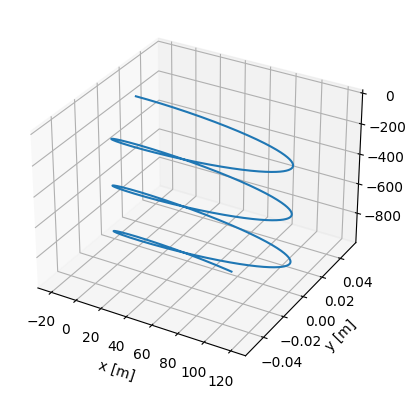

In [64]:
fig , ax = plt.figure() , plt.axes(projection = '3d')
ax.plot3D(Yr[:,0],Yr[:,1],Yr[:,2])
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
plt.show()

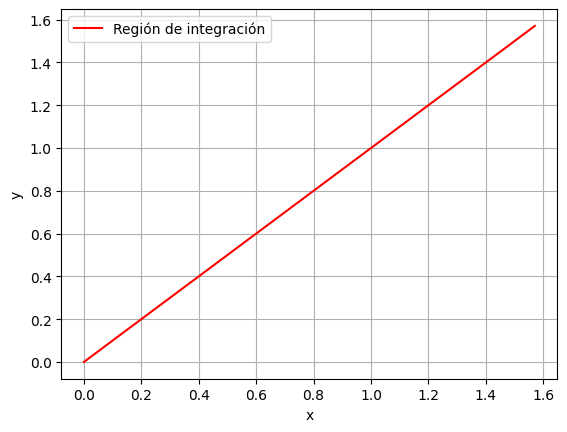

In [5]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0,1,200)
x  , y = np.pi/2*t , np.pi/2*t

plt.plot(x,y,c='r', label='Región de integración')
#plt.plot(x,0*y , c= 'r')
#plt.plot(0*x + np.pi/2 ,y , c= 'r')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()

In [9]:
import numpy as np

deltas = np.array([0.000001 , 0.00001 , 0.0001 , 0.001 , 0.01])

def limite (f,p):
    print('Valores por izquierda: ', p-deltas , '\n' , f(p-deltas),'\n')
    print('Valor por derecha: \n' ,p+deltas , '\n' , f(p+deltas) )

def func1(x):
    return (x**2 + x -6)/(x-3)

def func2(x):
    return np.exp(x)/(x-1)

def func3(x):
    return  (x-1)/x**3

def func4(x):
    return (np.sqrt(x)-2)/(x-4)

def func5(x):
    return (x-2)/(x**2 + x -6)

def func6(x):
    return (x-1)/(x**3-1)

def func7(x):
    return (np.exp(x)-1)/x

def func8(x):
    return np.sin(x)/x

def func9(x):
    return (np.sqrt(x)-2)/(x+4)

In [18]:
limite(func9,4)

Valores por izquierda:  [3.999999 3.99999  3.9999   3.999    3.99    ] 
 [-3.12500059e-08 -3.12500586e-07 -3.12505859e-06 -3.12558604e-05
 -3.13086916e-04] 

Valor por derecha: 
 [4.000001 4.00001  4.0001   4.001    4.01    ] 
 [3.12499941e-08 3.12499414e-07 3.12494141e-06 3.12441416e-05
 3.11915037e-04]
